In [1]:
import pandas as pd

df = pd.read_csv("./data/DSI_kickstarterscrape_dataset.csv", encoding="latin-1")

print("Number of rows", len(df))
df.head()

Number of rows 45957


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,138119,STRUM,http://www.kickstarter.com/projects/185476022/...,Film & Video,Animation,"Los Angeles, CA",live,20000.0,56.0,0.002800,3,"Fri, 08 Jun 2012 00:00:31 -0000",10,"$1,$10,$25,$40,$50,$100,$250,$1,000,$1,337,$9,001",1,0,28.00
3,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
4,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00


In [ ]:
df = df.drop_duplicates(subset=["project id"])


df['duration'] = df['duration'].apply(lambda x: x if isinstance(x, (int, float)) else None)

df = df.dropna(subset=['duration'])



45815

Completed campaigns: 41,841
  Successful: 22,902
  Failed:     18,939



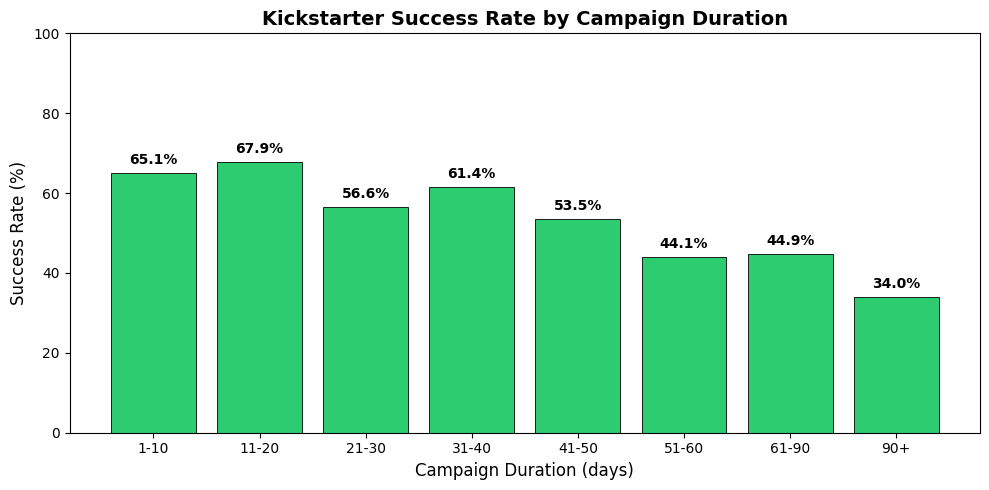

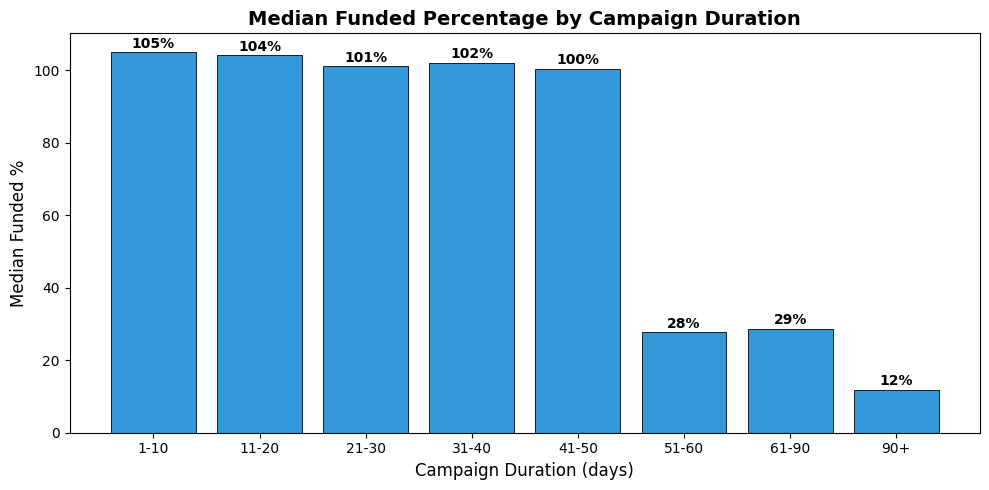

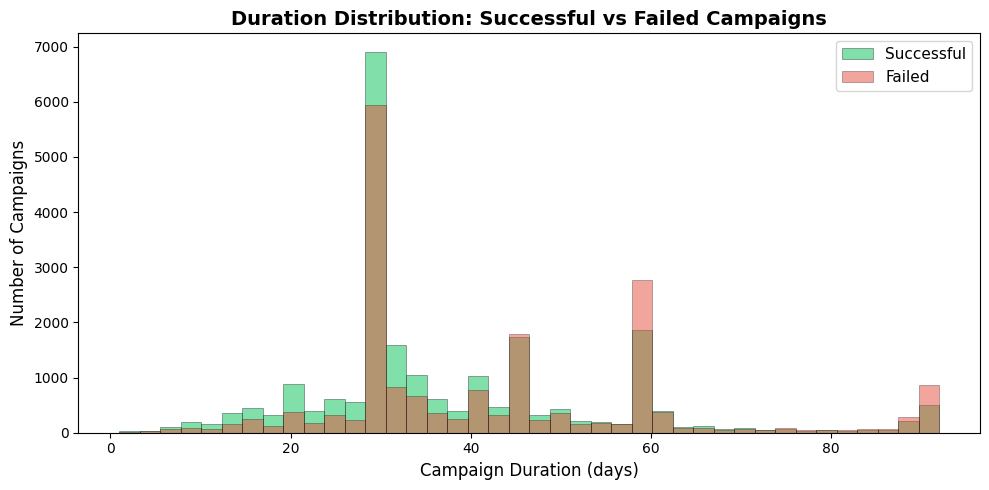

── Summary by Duration Bin ──


,Duration (days),Campaign Count,Success Rate,Median Funded %,Median Pledged ($),Median Backers
0,1-10,553,65.1%,105%,$542,13
1,11-20,2338,67.9%,104%,"$1,006",21
2,21-30,14769,56.6%,101%,"$1,356",24
3,31-40,7904,61.4%,102%,"$2,126",33
4,41-50,6222,53.5%,100%,"$1,837",29
5,51-60,5076,44.1%,28%,"$1,110",18
6,61-90,4426,44.9%,29%,"$1,150",19
7,90+,553,34.0%,12%,$710,11



── Recommendation ──
Campaigns lasting 11-20 days have the highest success rate (67.9%).
Shorter campaigns (under ~30 days) tend to outperform longer ones.
Beyond 30 days success rates decline steadily — urgency drives backers to act.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Data prep ─────────────────────────────────────────────────────────────
completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

bins  = [0, 10, 20, 30, 40, 50, 60, 90, float('inf')]
labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-90', '90+']
completed['duration_bin'] = pd.cut(completed['duration'], bins=bins, labels=labels, right=True)

print(f"Completed campaigns: {len(completed):,}")
print(f"  Successful: {completed['is_successful'].sum():,}")
print(f"  Failed:     {(~completed['is_successful'].astype(bool)).sum():,}\n")

# ── 2. Success rate by duration bin ──────────────────────────────────────────
summary = completed.groupby('duration_bin', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
    median_funded_pct=('funded percentage', 'median'),
    median_pledged=('pledged', 'median'),
    median_backers=('backers', 'median'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(summary['duration_bin'], summary['success_rate'] * 100,
              color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Campaign Duration (days)', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Kickstarter Success Rate by Campaign Duration', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, summary['success_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Median funded percentage by duration bin ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(summary['duration_bin'], summary['median_funded_pct'] * 100,
              color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Campaign Duration (days)', fontsize=12)
ax.set_ylabel('Median Funded %', fontsize=12)
ax.set_title('Median Funded Percentage by Campaign Duration', fontsize=14, fontweight='bold')
for bar, val in zip(bars, summary['median_funded_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Duration distribution: successful vs failed ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(completed.loc[completed['is_successful'] == 1, 'duration'],
        bins=40, alpha=0.6, label='Successful', color='#2ecc71', edgecolor='black', linewidth=0.4)
ax.hist(completed.loc[completed['is_successful'] == 0, 'duration'],
        bins=40, alpha=0.5, label='Failed', color='#e74c3c', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Campaign Duration (days)', fontsize=12)
ax.set_ylabel('Number of Campaigns', fontsize=12)
ax.set_title('Duration Distribution: Successful vs Failed Campaigns', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── 5. Summary statistics table ──────────────────────────────────────────────
display_df = summary.copy()
display_df.columns = ['Duration (days)', 'Campaign Count', 'Success Rate',
                       'Median Funded %', 'Median Pledged ($)', 'Median Backers']
display_df['Success Rate'] = display_df['Success Rate'].map('{:.1%}'.format)
display_df['Median Funded %'] = display_df['Median Funded %'].map('{:.0%}'.format)
display_df['Median Pledged ($)'] = display_df['Median Pledged ($)'].map('${:,.0f}'.format)
display_df['Median Backers'] = display_df['Median Backers'].astype(int)
print("── Summary by Duration Bin ──")
display(display_df)

# ── 6. Conclusion ────────────────────────────────────────────────────────────
best_bin = summary.loc[summary['success_rate'].idxmax()]
print("\n── Recommendation ──")
print(f"Campaigns lasting {best_bin['duration_bin']} days have the highest success rate "
      f"({best_bin['success_rate']:.1%}).")
print("Shorter campaigns (under ~30 days) tend to outperform longer ones.")
print("Beyond 30 days success rates decline steadily — urgency drives backers to act.")

Completed campaigns: 41,841
  Successful: 22,902
  Failed:     18,939



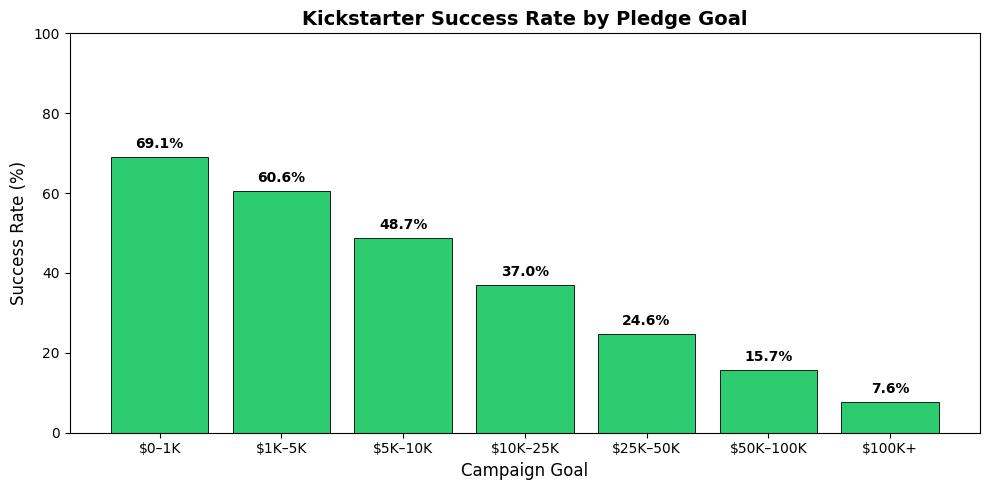

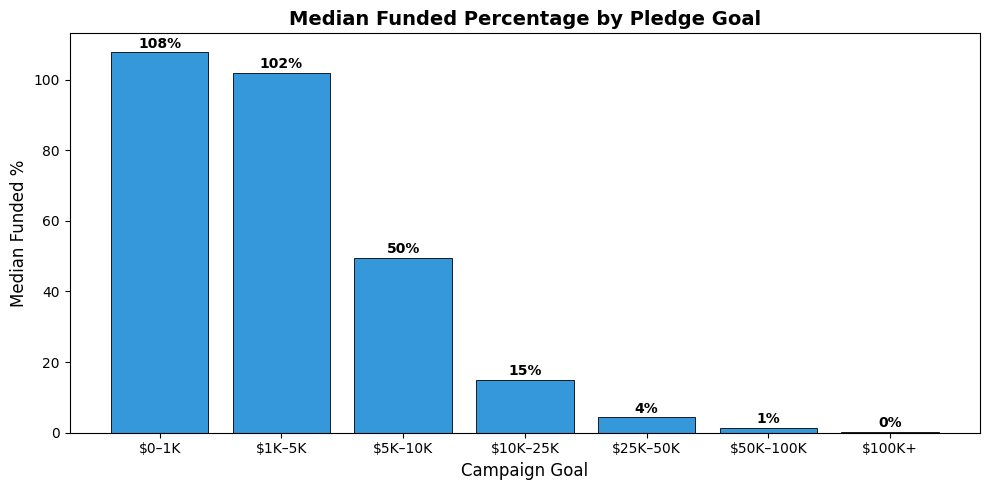

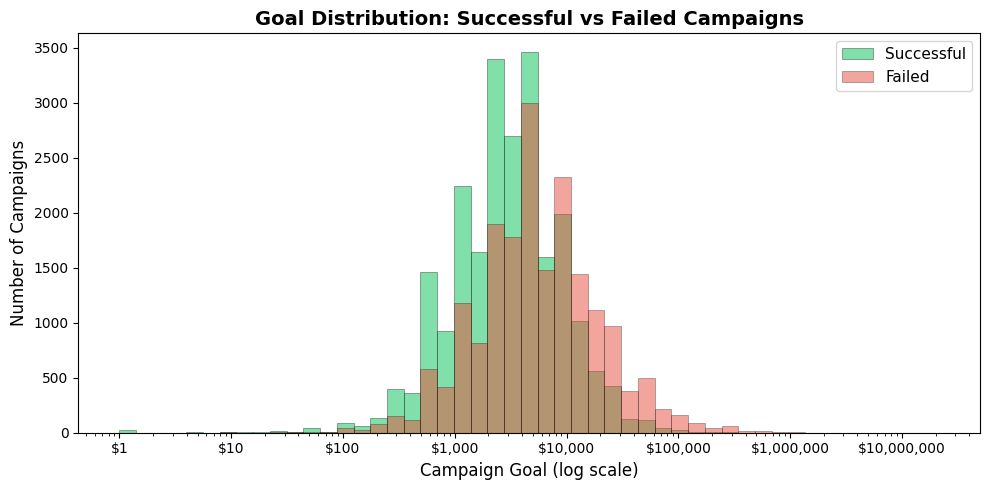

── Summary by Goal Range ──


,Goal Range,Campaign Count,Success Rate,Median Funded %,Median Pledged ($),Median Backers
0,$0–1K,7352,69.1%,108%,$606,15
1,$1K–5K,19196,60.6%,102%,"$2,060",30
2,$5K–10K,7848,48.7%,50%,"$4,056",38
3,$10K–25K,5104,37.0%,15%,"$2,524",30
4,$25K–50K,1474,24.6%,4%,"$1,528",20
5,$50K–100K,578,15.7%,1%,"$1,096",11
6,$100K+,289,7.6%,0%,$481,6



── Recommendation ──
Campaigns with a goal of $0–1K have the highest success rate (69.1%).
Lower goals consistently outperform higher ones — smaller asks are easier
to fully fund, and reaching 100% early creates momentum that attracts more backers.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Data prep ─────────────────────────────────────────────────────────────
completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

goal_bins   = [0, 1_000, 5_000, 10_000, 25_000, 50_000, 100_000, float('inf')]
goal_labels = ['$0–1K', '$1K–5K', '$5K–10K', '$10K–25K', '$25K–50K', '$50K–100K', '$100K+']
completed['goal_bin'] = pd.cut(completed['goal'], bins=goal_bins, labels=goal_labels, right=True)

print(f"Completed campaigns: {len(completed):,}")
print(f"  Successful: {completed['is_successful'].sum():,}")
print(f"  Failed:     {(~completed['is_successful'].astype(bool)).sum():,}\n")

# ── 2. Success rate by goal bin ──────────────────────────────────────────────
goal_summary = completed.groupby('goal_bin', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
    median_funded_pct=('funded percentage', 'median'),
    median_pledged=('pledged', 'median'),
    median_backers=('backers', 'median'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(goal_summary['goal_bin'], goal_summary['success_rate'] * 100,
              color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Campaign Goal', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Kickstarter Success Rate by Pledge Goal', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, goal_summary['success_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Median funded percentage by goal bin ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(goal_summary['goal_bin'], goal_summary['median_funded_pct'] * 100,
              color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Campaign Goal', fontsize=12)
ax.set_ylabel('Median Funded %', fontsize=12)
ax.set_title('Median Funded Percentage by Pledge Goal', fontsize=14, fontweight='bold')
for bar, val in zip(bars, goal_summary['median_funded_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Goal distribution: successful vs failed (log-scale) ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
successful_goals = completed.loc[completed['is_successful'] == 1, 'goal'].dropna()
failed_goals     = completed.loc[completed['is_successful'] == 0, 'goal'].dropna()

log_bins = np.logspace(
    np.log10(max(completed['goal'].min(), 1)),
    np.log10(completed['goal'].max()),
    50,
)

ax.hist(successful_goals, bins=log_bins, alpha=0.6, label='Successful',
        color='#2ecc71', edgecolor='black', linewidth=0.4)
ax.hist(failed_goals, bins=log_bins, alpha=0.5, label='Failed',
        color='#e74c3c', edgecolor='black', linewidth=0.4)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('Campaign Goal (log scale)', fontsize=12)
ax.set_ylabel('Number of Campaigns', fontsize=12)
ax.set_title('Goal Distribution: Successful vs Failed Campaigns', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── 5. Summary statistics table ──────────────────────────────────────────────
display_df = goal_summary.copy()
display_df.columns = ['Goal Range', 'Campaign Count', 'Success Rate',
                       'Median Funded %', 'Median Pledged ($)', 'Median Backers']
display_df['Success Rate']       = display_df['Success Rate'].map('{:.1%}'.format)
display_df['Median Funded %']    = display_df['Median Funded %'].map('{:.0%}'.format)
display_df['Median Pledged ($)'] = display_df['Median Pledged ($)'].map('${:,.0f}'.format)
display_df['Median Backers']     = display_df['Median Backers'].astype(int)
print("── Summary by Goal Range ──")
display(display_df)

# ── 6. Conclusion ────────────────────────────────────────────────────────────
best = goal_summary.loc[goal_summary['success_rate'].idxmax()]
print("\n── Recommendation ──")
print(f"Campaigns with a goal of {best['goal_bin']} have the highest success rate "
      f"({best['success_rate']:.1%}).")
print("Lower goals consistently outperform higher ones — smaller asks are easier")
print("to fully fund, and reaching 100% early creates momentum that attracts more backers.")

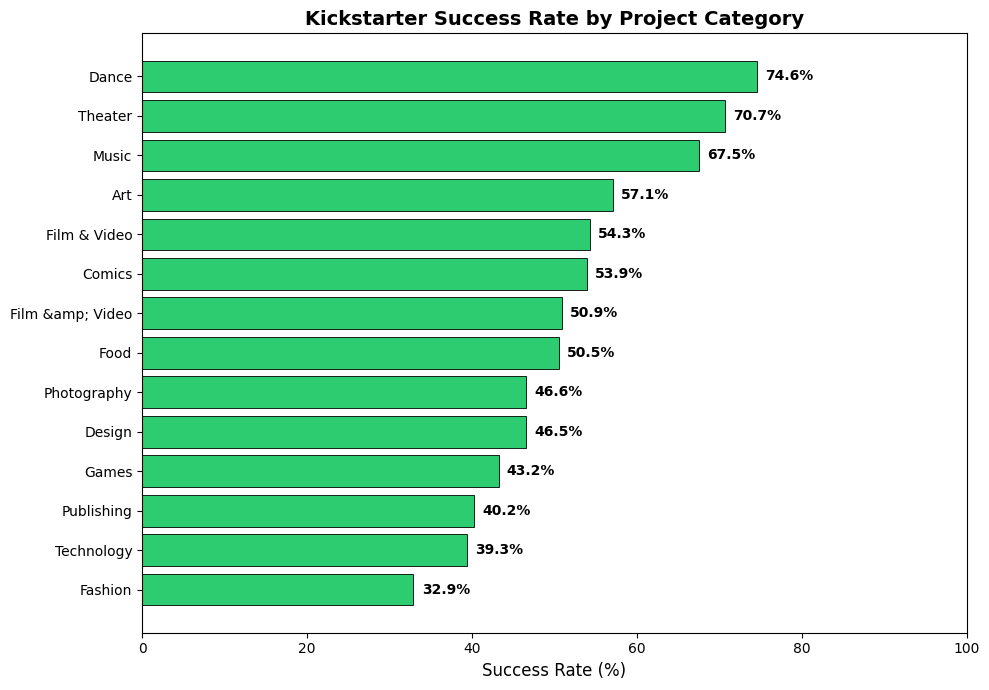

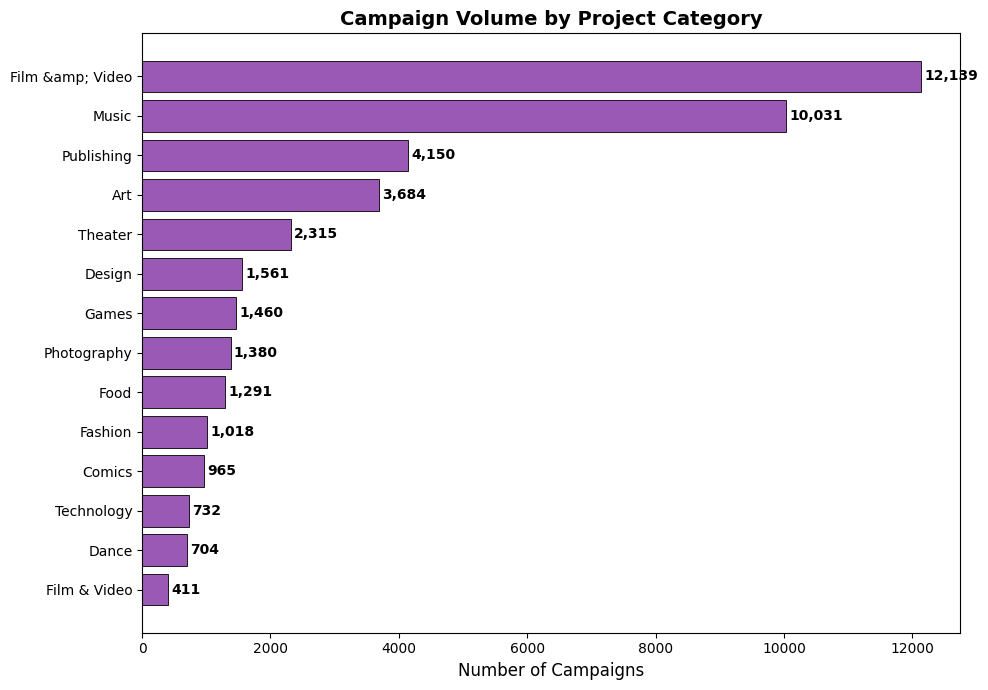

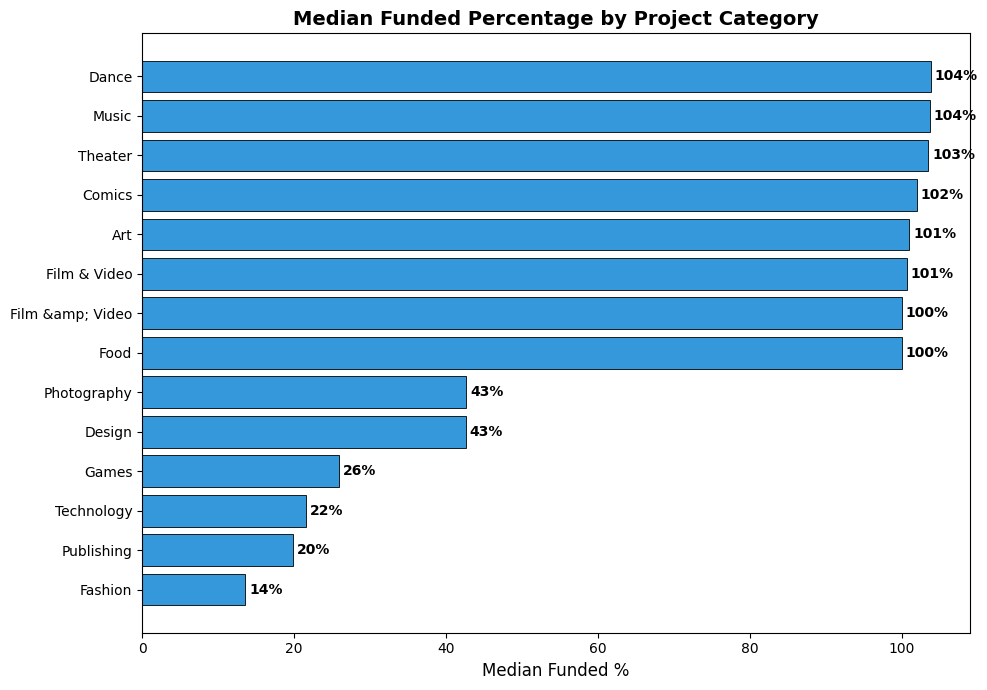

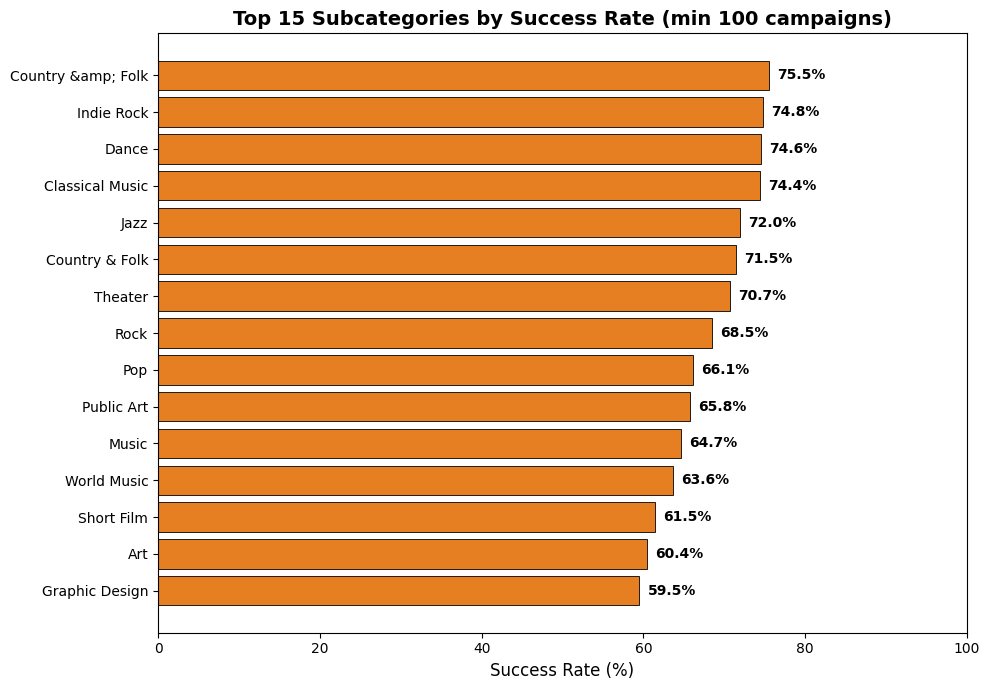

── Summary by Category (sorted by success rate) ──


,Category,Campaign Count,Success Rate,Median Funded %,Median Pledged ($),Median Backers
0,Dance,704,74.6%,104%,"$2,090",31
1,Theater,2315,70.7%,103%,"$1,871",31
2,Music,10031,67.5%,104%,"$2,002",34
3,Art,3684,57.1%,101%,"$1,145",23
4,Film & Video,411,54.3%,101%,"$1,685",23
5,Comics,965,53.9%,102%,"$1,083",25
6,Film &amp; Video,12139,50.9%,100%,"$1,471",21
7,Food,1291,50.5%,100%,"$2,500",36
8,Photography,1380,46.6%,43%,$920,17
9,Design,1561,46.5%,43%,"$1,792",31



── Recommendation ──
Top 3 project categories by success rate:
  1. Dance — 74.6% (704 campaigns)
  2. Theater — 70.7% (2,315 campaigns)
  3. Music — 67.5% (10,031 campaigns)

High volume matters too: a category with thousands of campaigns and a solid
success rate is a safer bet than a niche category with very few data points.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Data prep ─────────────────────────────────────────────────────────────
completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

cat_summary = completed.groupby('category', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
    median_funded_pct=('funded percentage', 'median'),
    median_pledged=('pledged', 'median'),
    median_backers=('backers', 'median'),
).reset_index().sort_values('success_rate', ascending=True)

# ── 2. Success rate by category ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cat_summary['category'], cat_summary['success_rate'] * 100,
               color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Success Rate (%)', fontsize=12)
ax.set_title('Kickstarter Success Rate by Project Category', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
for bar, rate in zip(bars, cat_summary['success_rate']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{rate:.1%}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Campaign volume by category ──────────────────────────────────────────
vol_sorted = cat_summary.sort_values('count', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(vol_sorted['category'], vol_sorted['count'],
               color='#9b59b6', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Number of Campaigns', fontsize=12)
ax.set_title('Campaign Volume by Project Category', fontsize=14, fontweight='bold')
for bar, cnt in zip(bars, vol_sorted['count']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Median funded percentage by category ──────────────────────────────────
funded_sorted = cat_summary.sort_values('median_funded_pct', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(funded_sorted['category'], funded_sorted['median_funded_pct'] * 100,
               color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Median Funded %', fontsize=12)
ax.set_title('Median Funded Percentage by Project Category', fontsize=14, fontweight='bold')
for bar, val in zip(bars, funded_sorted['median_funded_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0%}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Top subcategories by success rate ─────────────────────────────────────
sub_summary = completed.groupby('subcategory', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reset_index()

sub_filtered = sub_summary[sub_summary['count'] >= 100].sort_values('success_rate', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(sub_filtered['subcategory'], sub_filtered['success_rate'] * 100,
               color='#e67e22', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Success Rate (%)', fontsize=12)
ax.set_title('Top 15 Subcategories by Success Rate (min 100 campaigns)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
for bar, rate in zip(bars, sub_filtered['success_rate']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{rate:.1%}', ha='left', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Summary statistics table ──────────────────────────────────────────────
display_df = cat_summary.sort_values('success_rate', ascending=False).copy()
display_df.columns = ['Category', 'Campaign Count', 'Success Rate',
                       'Median Funded %', 'Median Pledged ($)', 'Median Backers']
display_df['Success Rate']       = display_df['Success Rate'].map('{:.1%}'.format)
display_df['Median Funded %']    = display_df['Median Funded %'].map('{:.0%}'.format)
display_df['Median Pledged ($)'] = display_df['Median Pledged ($)'].map('${:,.0f}'.format)
display_df['Median Backers']     = display_df['Median Backers'].astype(int)
print("── Summary by Category (sorted by success rate) ──")
display(display_df.reset_index(drop=True))

# ── 7. Conclusion ────────────────────────────────────────────────────────────
top3 = cat_summary.sort_values('success_rate', ascending=False).head(3)
print("\n── Recommendation ──")
print("Top 3 project categories by success rate:")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {row['category']} — {row['success_rate']:.1%} "
          f"({row['count']:,} campaigns)")
print("\nHigh volume matters too: a category with thousands of campaigns and a solid")
print("success rate is a safer bet than a niche category with very few data points.")

Campaigns with valid launch dates: 41,841



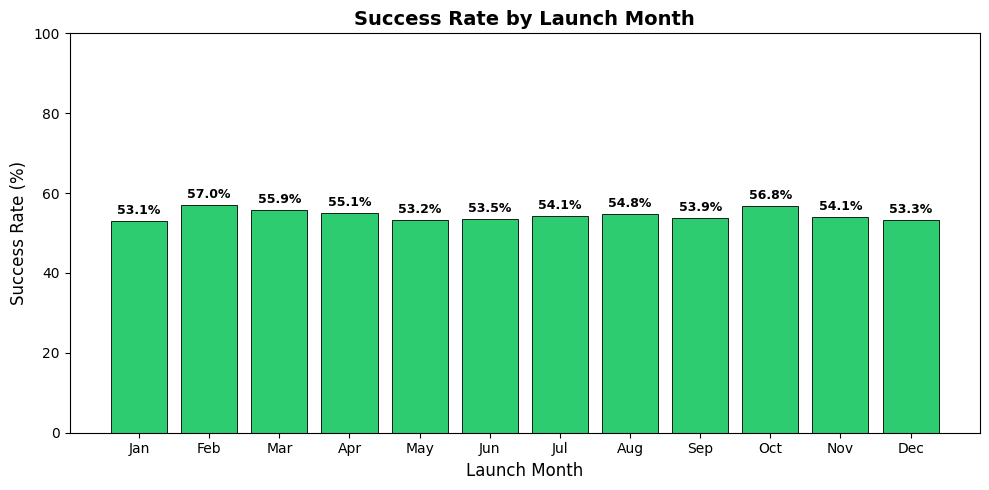

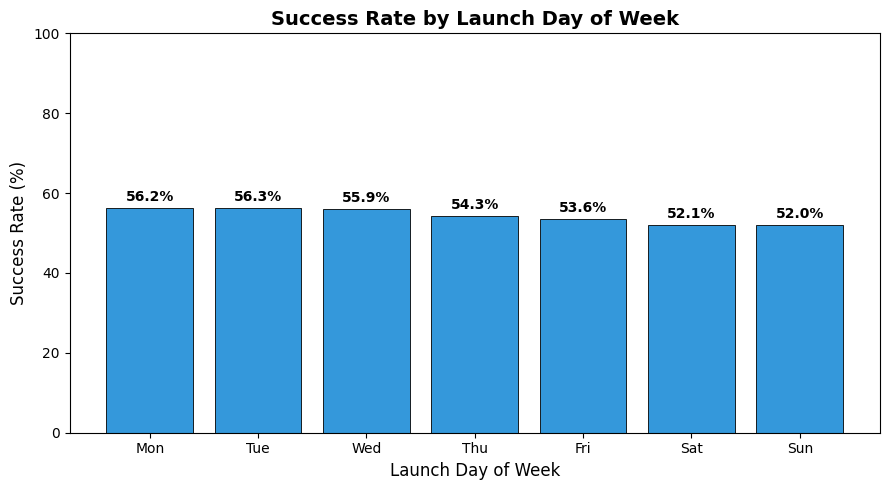

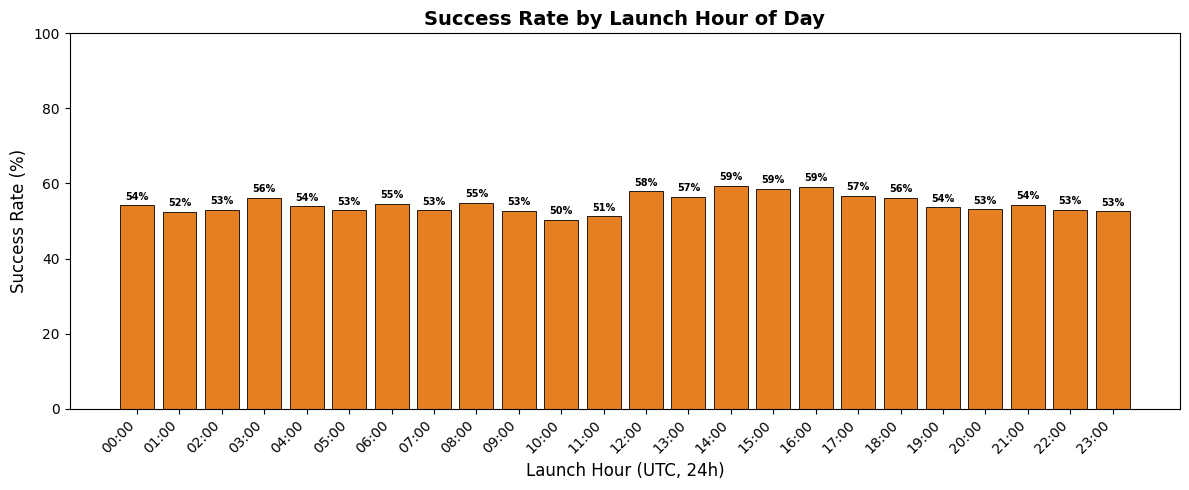

── Success Rate by Month ──


,Campaigns,Success Rate
Jan,3749,53.1%
Feb,4475,57.0%
Mar,5337,55.9%
Apr,4995,55.1%
May,3082,53.2%
Jun,2781,53.5%
Jul,2776,54.1%
Aug,2644,54.8%
Sep,2840,53.9%
Oct,2982,56.8%



── Success Rate by Day of Week ──


,Campaigns,Success Rate
Mon,6521,56.2%
Tue,7395,56.3%
Wed,7183,55.9%
Thu,7148,54.3%
Fri,6415,53.6%
Sat,4084,52.1%
Sun,3095,52.0%



── Success Rate by Hour (UTC) ──


,Campaigns,Success Rate
00:00,2288,54.2%
01:00,2155,52.4%
02:00,2070,53.0%
03:00,2071,56.1%
04:00,1918,53.9%
05:00,1610,52.9%
06:00,1235,54.6%
07:00,895,52.8%
08:00,624,54.8%
09:00,412,52.7%



── Recommendation ──
Best month to launch:  February (57.0% success rate)
Best day of the week:  Tue (56.3% success rate)
Best hour (UTC):       14:00 (59.4% success rate)

Note: hour-level differences tend to be small. Month and day of week
show more meaningful variation in success rates.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from email.utils import parsedate_to_datetime
import calendar

# ── 1. Data prep ─────────────────────────────────────────────────────────────
completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

completed['funded_dt'] = completed['funded date'].apply(
    lambda x: parsedate_to_datetime(x) if isinstance(x, str) else pd.NaT
)
completed = completed.dropna(subset=['funded_dt'])

completed['launch_date'] = completed['funded_dt'] - completed['duration'].apply(lambda d: timedelta(days=d))

completed['launch_month'] = completed['launch_date'].dt.month
completed['launch_dow']   = completed['launch_date'].dt.dayofweek   # 0=Mon … 6=Sun
completed['launch_hour']  = completed['launch_date'].dt.hour

month_names = [calendar.month_abbr[m] for m in range(1, 13)]
dow_names   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print(f"Campaigns with valid launch dates: {len(completed):,}\n")

# ── 2. Success rate by launch month ──────────────────────────────────────────
month_summary = completed.groupby('launch_month').agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(month_names, month_summary['success_rate'] * 100,
              color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Launch Month', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Launch Month', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, month_summary['success_rate']):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Success rate by day of week ───────────────────────────────────────────
dow_summary = completed.groupby('launch_dow').agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reindex(range(7))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dow_names, dow_summary['success_rate'] * 100,
              color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Launch Day of Week', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Launch Day of Week', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, dow_summary['success_rate']):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Success rate by hour of day ───────────────────────────────────────────
hour_summary = completed.groupby('launch_hour').agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reindex(range(24))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(24), hour_summary['success_rate'] * 100,
              color='#e67e22', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Launch Hour (UTC, 24h)', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Launch Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_ylim(0, 100)
for bar, rate in zip(bars, hour_summary['success_rate']):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{rate:.0%}', ha='center', va='bottom', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Summary statistics tables ─────────────────────────────────────────────
print("── Success Rate by Month ──")
m_disp = month_summary.copy()
m_disp.index = month_names
m_disp.columns = ['Campaigns', 'Success Rate']
m_disp['Campaigns'] = m_disp['Campaigns'].astype(int)
m_disp['Success Rate'] = m_disp['Success Rate'].map('{:.1%}'.format)
display(m_disp)

print("\n── Success Rate by Day of Week ──")
d_disp = dow_summary.copy()
d_disp.index = dow_names
d_disp.columns = ['Campaigns', 'Success Rate']
d_disp['Campaigns'] = d_disp['Campaigns'].astype(int)
d_disp['Success Rate'] = d_disp['Success Rate'].map('{:.1%}'.format)
display(d_disp)

print("\n── Success Rate by Hour (UTC) ──")
h_disp = hour_summary.copy()
h_disp.index = [f'{h:02d}:00' for h in range(24)]
h_disp.columns = ['Campaigns', 'Success Rate']
h_disp['Campaigns'] = h_disp['Campaigns'].astype(int)
h_disp['Success Rate'] = h_disp['Success Rate'].map('{:.1%}'.format)
display(h_disp)

# ── 6. Conclusion ────────────────────────────────────────────────────────────
best_month = month_summary['success_rate'].idxmax()
best_dow   = dow_summary['success_rate'].idxmax()
best_hour  = hour_summary['success_rate'].idxmax()

print("\n── Recommendation ──")
print(f"Best month to launch:  {calendar.month_name[best_month]} "
      f"({month_summary.loc[best_month, 'success_rate']:.1%} success rate)")
print(f"Best day of the week:  {dow_names[best_dow]} "
      f"({dow_summary.loc[best_dow, 'success_rate']:.1%} success rate)")
print(f"Best hour (UTC):       {best_hour:02d}:00 "
      f"({hour_summary.loc[best_hour, 'success_rate']:.1%} success rate)")
print("\nNote: hour-level differences tend to be small. Month and day of week")
print("show more meaningful variation in success rates.")

Campaigns with valid engagement data: 41,841

── Average Engagement by Status ──


updates        comments       
              mean median     mean median
status                                   
failed        1.49    0.0     0.96    0.0
successful    6.69    5.0    14.42    2.0

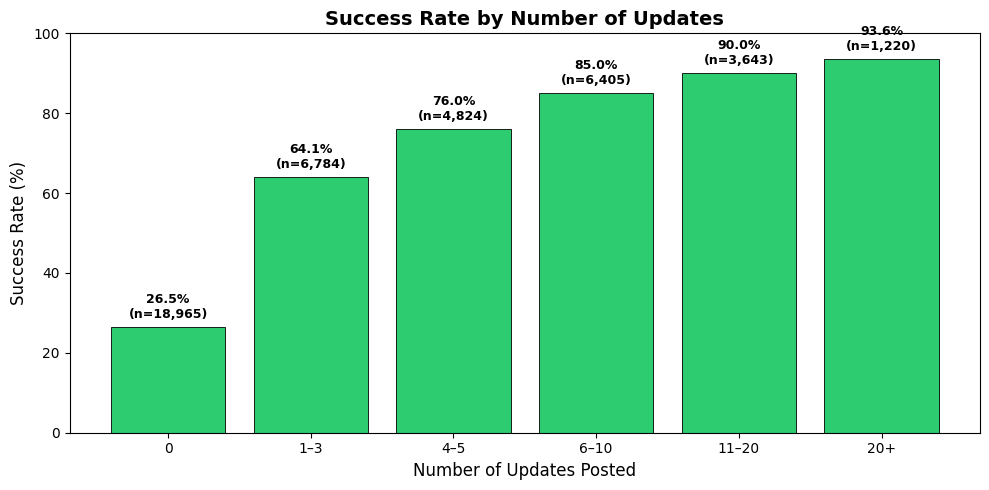

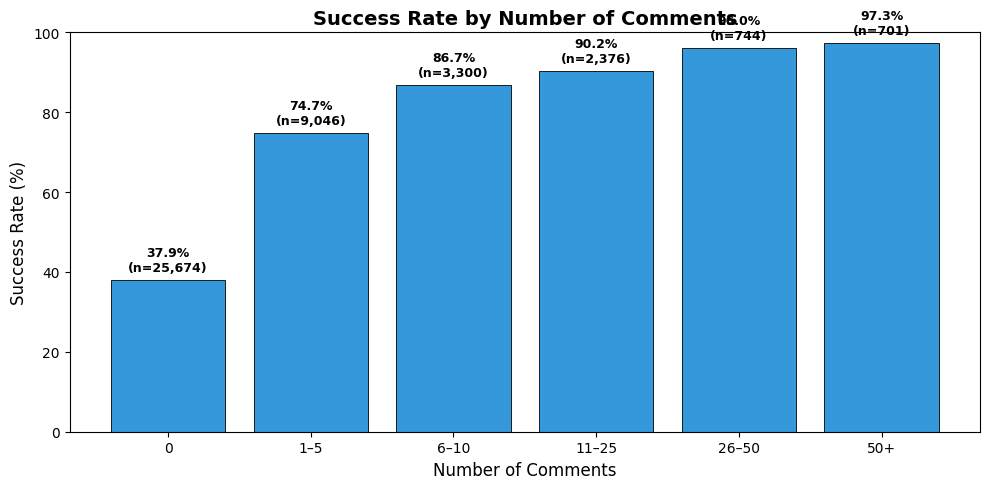

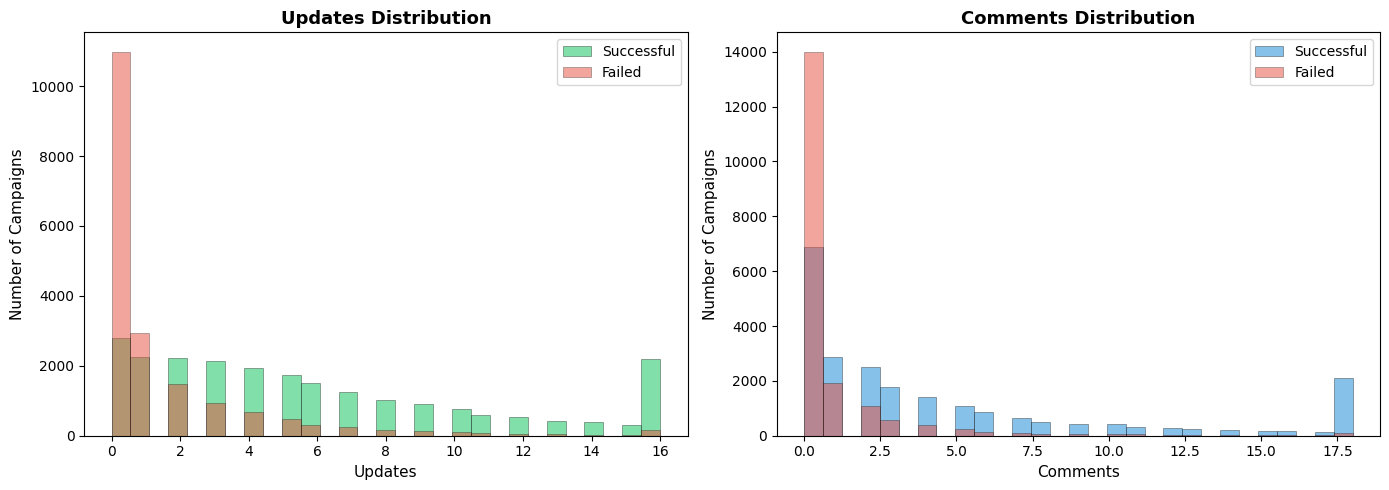

── Correlation with Success ──
  Updates:  r = 0.390  (p = 0.00e+00)
  Comments: r = 0.038  (p = 5.69e-15)

── Updates Summary ──


,Updates,Campaigns,Success Rate
0,0,"18,965",26.5%
1,1–3,"6,784",64.1%
2,4–5,"4,824",76.0%
3,6–10,"6,405",85.0%
4,11–20,"3,643",90.0%
5,20+,"1,220",93.6%



── Comments Summary ──


,Comments,Campaigns,Success Rate
0,0,"25,674",37.9%
1,1–5,"9,046",74.7%
2,6–10,"3,300",86.7%
3,11–25,"2,376",90.2%
4,26–50,744,96.0%
5,50+,701,97.3%



── Recommendation ──
Engagement is strongly associated with success:
  - Campaigns with 20+ updates have a 93.6% success rate
    vs 26.5% for campaigns with 0 updates.
  - Campaigns with 50+ comments have a 97.3% success rate
    vs 37.9% for campaigns with 0 comments.

Both updates (r=0.390) and comments (r=0.038) show a statistically
significant positive correlation with success. Regular creator updates
and active backer discussion are strong signals of — and contributors to —
a campaign's likelihood of getting funded.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Data prep ─────────────────────────────────────────────────────────────
completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

completed['updates']  = pd.to_numeric(completed['updates'],  errors='coerce')
completed['comments'] = pd.to_numeric(completed['comments'], errors='coerce')
completed = completed.dropna(subset=['updates', 'comments'])

print(f"Campaigns with valid engagement data: {len(completed):,}\n")

# ── 2. Average updates & comments: successful vs failed ─────────────────────
eng_by_status = completed.groupby('status')[['updates', 'comments']].agg(['mean', 'median'])
print("── Average Engagement by Status ──")
display(eng_by_status.round(2))

# ── 3. Success rate by number of updates (binned) ───────────────────────────
update_bins   = [0, 1, 3, 5, 10, 20, float('inf')]
update_labels = ['0', '1–3', '4–5', '6–10', '11–20', '20+']
completed['update_bin'] = pd.cut(completed['updates'], bins=update_bins,
                                  labels=update_labels, right=True, include_lowest=True)

upd_summary = completed.groupby('update_bin', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(upd_summary['update_bin'], upd_summary['success_rate'] * 100,
              color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Number of Updates Posted', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Number of Updates', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate, cnt in zip(bars, upd_summary['success_rate'], upd_summary['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{rate:.1%}\n(n={cnt:,})', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Success rate by number of comments (binned) ──────────────────────────
comment_bins   = [0, 1, 5, 10, 25, 50, float('inf')]
comment_labels = ['0', '1–5', '6–10', '11–25', '26–50', '50+']
completed['comment_bin'] = pd.cut(completed['comments'], bins=comment_bins,
                                   labels=comment_labels, right=True, include_lowest=True)

cmt_summary = completed.groupby('comment_bin', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cmt_summary['comment_bin'], cmt_summary['success_rate'] * 100,
              color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Number of Comments', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Number of Comments', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for bar, rate, cnt in zip(bars, cmt_summary['success_rate'], cmt_summary['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{rate:.1%}\n(n={cnt:,})', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Distribution: updates & comments for successful vs failed ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color_s, color_f, title in [
    (axes[0], 'updates',  '#2ecc71', '#e74c3c', 'Updates Distribution'),
    (axes[1], 'comments', '#3498db', '#e74c3c', 'Comments Distribution'),
]:
    cap = completed[col].quantile(0.95)
    succ = completed.loc[completed['is_successful'] == 1, col].clip(upper=cap)
    fail = completed.loc[completed['is_successful'] == 0, col].clip(upper=cap)
    bins_hist = np.linspace(0, cap, 30)
    ax.hist(succ, bins=bins_hist, alpha=0.6, label='Successful', color=color_s, edgecolor='black', linewidth=0.4)
    ax.hist(fail, bins=bins_hist, alpha=0.5, label='Failed',     color=color_f, edgecolor='black', linewidth=0.4)
    ax.set_xlabel(col.capitalize(), fontsize=11)
    ax.set_ylabel('Number of Campaigns', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ── 6. Point-biserial correlation ────────────────────────────────────────────
from scipy.stats import pointbiserialr

r_upd, p_upd = pointbiserialr(completed['is_successful'], completed['updates'])
r_cmt, p_cmt = pointbiserialr(completed['is_successful'], completed['comments'])

print("── Correlation with Success ──")
print(f"  Updates:  r = {r_upd:.3f}  (p = {p_upd:.2e})")
print(f"  Comments: r = {r_cmt:.3f}  (p = {p_cmt:.2e})")

# ── 7. Summary table ─────────────────────────────────────────────────────────
print("\n── Updates Summary ──")
u_disp = upd_summary.copy()
u_disp.columns = ['Updates', 'Campaigns', 'Success Rate']
u_disp['Campaigns'] = u_disp['Campaigns'].map('{:,}'.format)
u_disp['Success Rate'] = u_disp['Success Rate'].map('{:.1%}'.format)
display(u_disp)

print("\n── Comments Summary ──")
c_disp = cmt_summary.copy()
c_disp.columns = ['Comments', 'Campaigns', 'Success Rate']
c_disp['Campaigns'] = c_disp['Campaigns'].map('{:,}'.format)
c_disp['Success Rate'] = c_disp['Success Rate'].map('{:.1%}'.format)
display(c_disp)

# ── 8. Conclusion ────────────────────────────────────────────────────────────
print("\n── Recommendation ──")
print("Engagement is strongly associated with success:")
print(f"  - Campaigns with 20+ updates have a {upd_summary.iloc[-1]['success_rate']:.1%} success rate")
print(f"    vs {upd_summary.iloc[0]['success_rate']:.1%} for campaigns with 0 updates.")
print(f"  - Campaigns with 50+ comments have a {cmt_summary.iloc[-1]['success_rate']:.1%} success rate")
print(f"    vs {cmt_summary.iloc[0]['success_rate']:.1%} for campaigns with 0 comments.")
print("\nBoth updates (r={:.3f}) and comments (r={:.3f}) show a statistically".format(r_upd, r_cmt))
print("significant positive correlation with success. Regular creator updates")
print("and active backer discussion are strong signals of — and contributors to —")
print("a campaign's likelihood of getting funded.")

Campaigns with valid U.S. state: 38,391



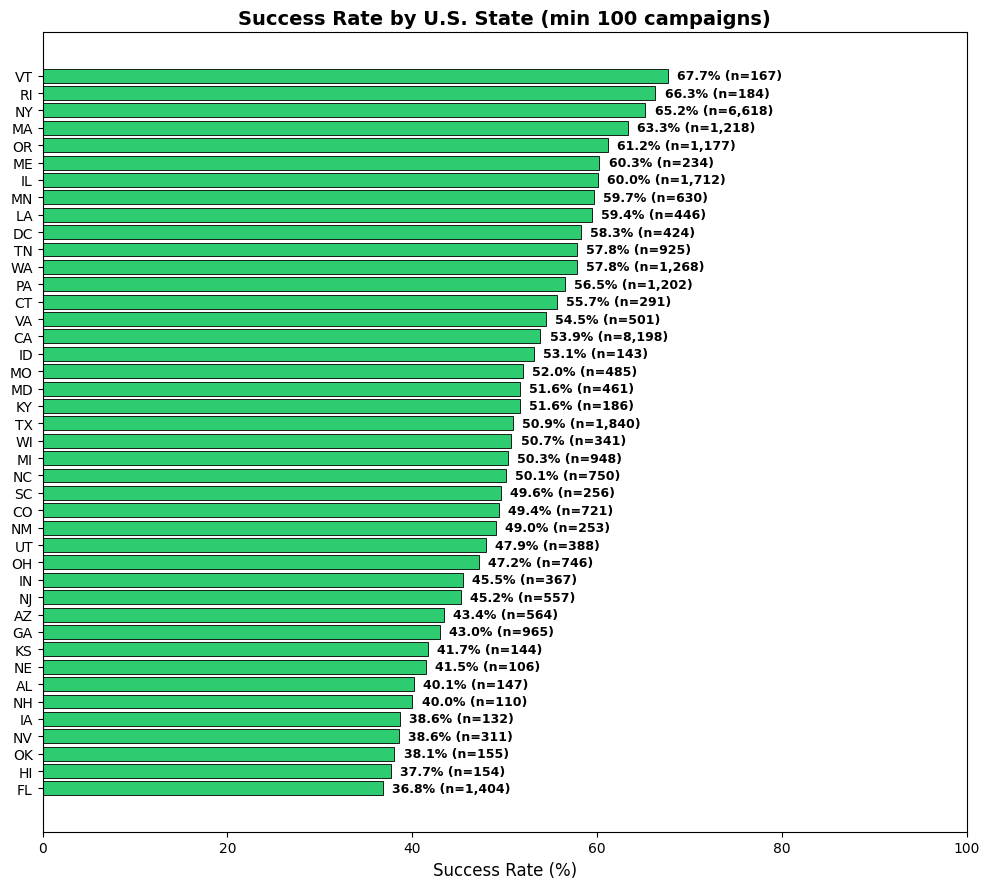

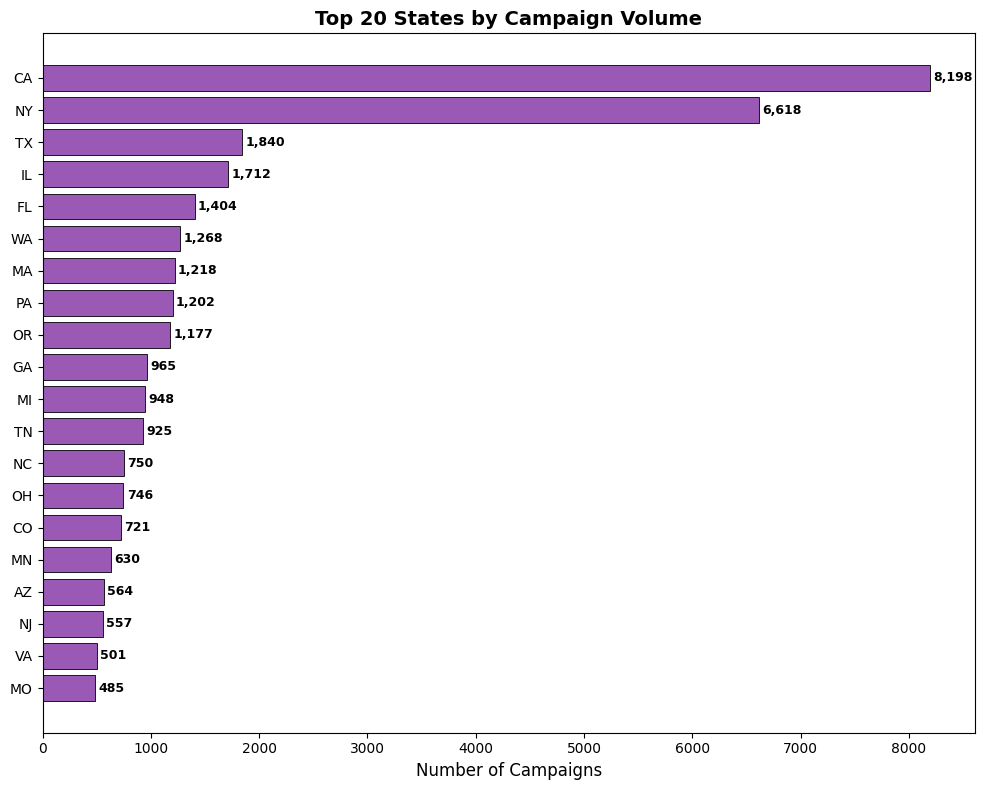

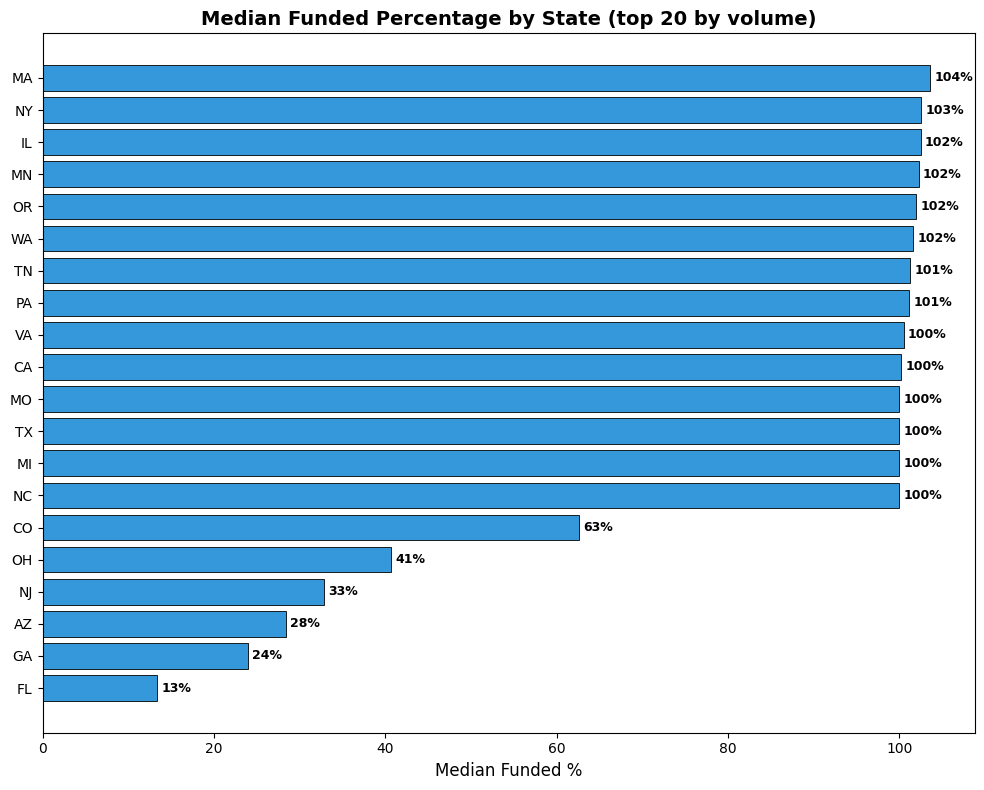

── Summary by State (min 100 campaigns, sorted by success rate) ──


,State,Campaigns,Success Rate,Median Funded %,Median Pledged ($),Median Backers
0,VT,167,67.7%,105%,"$1,859",33
1,RI,184,66.3%,105%,"$2,072",31
2,NY,6618,65.2%,103%,"$2,330",36
3,MA,1218,63.3%,104%,"$1,720",32
4,OR,1177,61.2%,102%,"$1,880",33
5,ME,234,60.3%,102%,"$1,508",27
6,IL,1712,60.0%,102%,"$1,492",28
7,MN,630,59.7%,102%,"$1,580",26
8,LA,446,59.4%,102%,"$1,555",28
9,DC,424,58.3%,102%,"$1,570",27



── Recommendation ──
Top 5 states by success rate (min 100 campaigns):
  1. VT — 67.7% (167 campaigns)
  2. RI — 66.3% (184 campaigns)
  3. NY — 65.2% (6,618 campaigns)
  4. MA — 63.3% (1,218 campaigns)
  5. OR — 61.2% (1,177 campaigns)

Location has a moderate effect on success, but it is secondary to factors
like goal size, campaign duration, category, and creator engagement.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Data prep ─────────────────────────────────────────────────────────────
US_STATES = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY','DC',
}

completed = df[df['status'].isin(['successful', 'failed'])].copy()
completed['is_successful'] = (completed['status'] == 'successful').astype(int)

completed['state'] = (
    completed['location']
    .astype(str)
    .str.strip()
    .str.split(', ')
    .str[-1]
    .str.strip()
)

completed = completed[completed['state'].isin(US_STATES)]

print(f"Campaigns with valid U.S. state: {len(completed):,}\n")

# ── 2. Success rate by state (min 100 campaigns, sorted) ────────────────────
state_summary = completed.groupby('state', observed=False).agg(
    count=('is_successful', 'size'),
    success_rate=('is_successful', 'mean'),
    median_funded_pct=('funded percentage', 'median'),
    median_pledged=('pledged', 'median'),
    median_backers=('backers', 'median'),
).reset_index()

MIN_CAMPAIGNS = 100
state_filtered = state_summary[state_summary['count'] >= MIN_CAMPAIGNS].copy()
state_filtered = state_filtered.sort_values('success_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(state_filtered['state'], state_filtered['success_rate'] * 100,
               color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Success Rate (%)', fontsize=12)
ax.set_title(f'Success Rate by U.S. State (min {MIN_CAMPAIGNS} campaigns)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
for bar, rate, cnt in zip(bars, state_filtered['success_rate'], state_filtered['count']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{rate:.1%} (n={cnt:,})', ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Campaign volume by state — top 20 ────────────────────────────────────
vol_top20 = state_summary.sort_values('count', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(vol_top20['state'], vol_top20['count'],
               color='#9b59b6', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Number of Campaigns', fontsize=12)
ax.set_title('Top 20 States by Campaign Volume', fontsize=14, fontweight='bold')
for bar, cnt in zip(bars, vol_top20['count']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Median funded % by state — top 20 by volume ──────────────────────────
top20_states = state_summary.nlargest(20, 'count')['state']
funded_top20 = state_filtered[state_filtered['state'].isin(top20_states)].sort_values(
    'median_funded_pct', ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(funded_top20['state'], funded_top20['median_funded_pct'] * 100,
               color='#3498db', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Median Funded %', fontsize=12)
ax.set_title('Median Funded Percentage by State (top 20 by volume)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, funded_top20['median_funded_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0%}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Summary statistics table ──────────────────────────────────────────────
display_df = state_filtered.sort_values('success_rate', ascending=False).copy()
display_df.columns = ['State', 'Campaigns', 'Success Rate',
                       'Median Funded %', 'Median Pledged ($)', 'Median Backers']
display_df['Success Rate']       = display_df['Success Rate'].map('{:.1%}'.format)
display_df['Median Funded %']    = display_df['Median Funded %'].map('{:.0%}'.format)
display_df['Median Pledged ($)'] = display_df['Median Pledged ($)'].map('${:,.0f}'.format)
display_df['Median Backers']     = display_df['Median Backers'].astype(int)
print(f"── Summary by State (min {MIN_CAMPAIGNS} campaigns, sorted by success rate) ──")
display(display_df.reset_index(drop=True))

# ── 6. Conclusion ────────────────────────────────────────────────────────────
top5 = state_filtered.sort_values('success_rate', ascending=False).head(5)
print("\n── Recommendation ──")
print(f"Top 5 states by success rate (min {MIN_CAMPAIGNS} campaigns):")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['state']} — {row['success_rate']:.1%} "
          f"({row['count']:,} campaigns)")
print("\nLocation has a moderate effect on success, but it is secondary to factors")
print("like goal size, campaign duration, category, and creator engagement.")